# Lab 31 — Wi-Fi, Bluetooth Low Energy, 802.15.4 and LoRa: Inside the Unlicensed Radios

**Companion to Chapter 22** (*Wi-Fi, Bluetooth and IoT*). Lab 11 simulates Wi-Fi contention and 4096-QAM; this lab builds the
rest of Chapter 22's radios from `commlib/iot.py`.
**Time needed:** about 2 hours. **Difficulty:** core.

The unlicensed bands host the most-used radios on Earth, and each is a different answer to the same question: what is the best
way to move bits when nobody owns the spectrum? Wi-Fi answers with speed, wide OFDM channels and a clever MAC; Bluetooth Low
Energy with a constant-envelope GFSK radio that sleeps 99.9% of the time; Zigbee/Thread with DSSS chips on an O-QPSK carrier;
LoRa with chirps that work 20 dB below the noise; passive RFID by not having a transmitter at all. This lab takes each apart.

### What you will learn
1. Detect an 802.11 packet from its short training field, estimate its frequency offset, and estimate the channel from the long training field.
2. Compute MAC efficiency with and without A-MPDU aggregation, the rate anomaly, and the gain of airtime fairness.
3. Watch a Minstrel-like rate-adaptation algorithm track a moving station.
4. Modulate and demodulate BLE GFSK, and estimate a coin-cell battery life from an advertising schedule.
5. Build the 802.15.4 chip table and its half-sine O-QPSK waveform and detect symbols by correlation.
6. Implement LoRa's chirp modulator and dechirp–FFT demodulator, measure SER against theory, and plan time on air, duty cycle,
   link budget and an RFID read range.

### Prerequisites
Lab 7 (OFDM), Lab 21 (GFSK/MSK), Lab 25 (spread spectrum), Lab 11 §7 (CSMA/CA). Chapter 22.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | 802.11 preamble: detection, CFO, channel estimation | yes |
| 2 | MAC efficiency, aggregation and the rate anomaly | yes |
| 3 | Rate adaptation | yes |
| 4 | Bluetooth Low Energy: GFSK and battery life | yes |
| 5 | IEEE 802.15.4: chips and O-QPSK | yes |
| 6 | LoRa and RFID: chirps, SER, time on air and range | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, spectrogram
import commlib as cl
from commlib import iot
from commlib import labkit as lk

rng = lk.setup(seed=31, lab="31")
cn = lambda r, n: (r.standard_normal(n) + 1j * r.standard_normal(n)) / np.sqrt(2)

Lab 31 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 31


## 1. 802.11 preamble: detection, CFO, channel estimation

Every 802.11 OFDM packet starts with the legacy preamble: the **L-STF**, ten repetitions of a 0.8 µs pattern (16 samples at
20 MS/s) used for packet detection, AGC and coarse frequency estimation, and the **L-LTF**, a 1.6 µs guard plus two copies of
a known 3.2 µs OFDM symbol used for fine timing, fine frequency and channel estimation. The receiver computes the delay-16
autocorrelation $P(n) = \sum r_{n+k}r^*_{n+k+16}$: on the STF its magnitude equals the energy (a plateau), and its angle is
$-2\pi\Delta f\cdot 16/f_s$, which measures offsets up to ±625 kHz. The LTF's two 64-sample copies refine the estimate to
±156 kHz with better accuracy, and dividing the FFT of their average by the known sequence gives the channel on 52 subcarriers.

### Interactive: SNR, offset and multipath

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

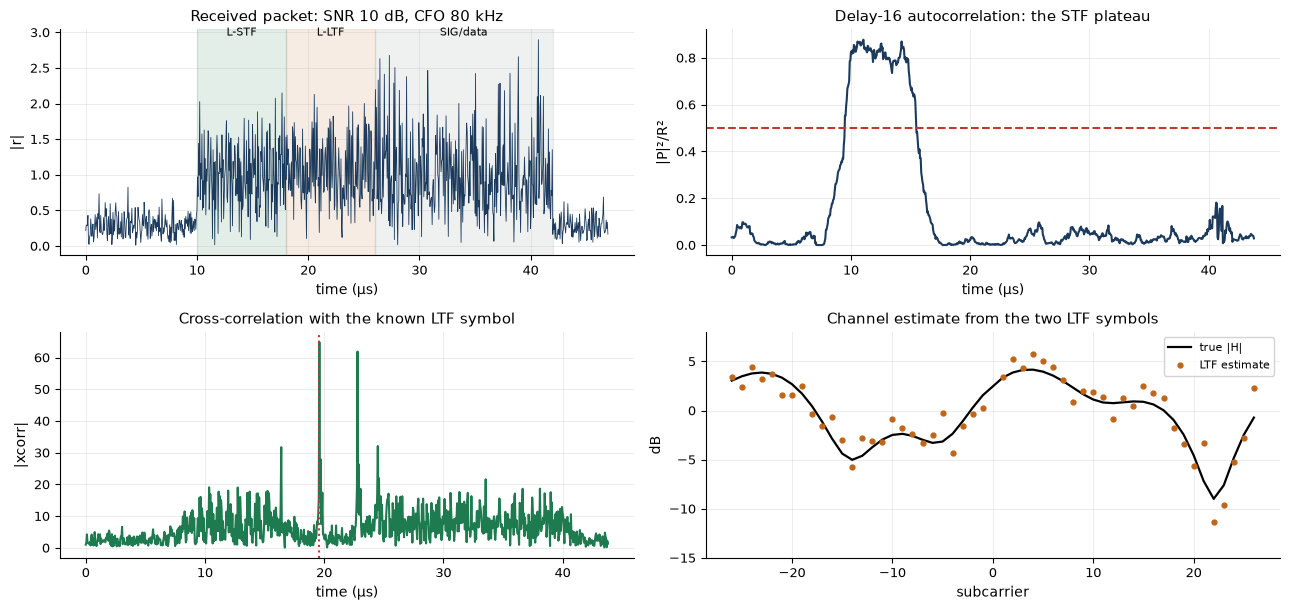

,
packet detected at,9.5 µs (true 10.0)
coarse CFO (STF),77.5 kHz
fine CFO (STF + LTF),80.22 kHz (true 80)
channel-estimate NMSE,-14.1 dB


In [3]:
L64 = np.zeros(64, complex)
for k_, v in zip(range(-26, 27), iot.wifi_ltf_freq()):
    L64[k_ % 64] = v
LTF_T = np.fft.ifft(L64) * 64 / np.sqrt(52)
USED = np.array([k_ % 64 for k_ in range(-26, 27) if k_ != 0])

def wifi_rx(snr_db, cfo_hz, h, r, lead=200):
    stf, ltf = iot.wifi_legacy_preamble()
    pkt = np.concatenate([stf, ltf, cn(r, 320)])
    x = np.concatenate([np.zeros(lead), np.convolve(pkt, h)[:len(pkt)], np.zeros(100)])
    x = x * np.exp(2j * np.pi * cfo_hz / 20e6 * np.arange(len(x)))
    return x + 10 ** (-snr_db / 20) * cn(r, len(x))

def wifi_sync(x, thr=0.5):
    m, P = iot.delay_correlate(x, 16, 48)
    above = np.flatnonzero(m > thr)
    if len(above) == 0:
        return None
    k0 = above[0]
    cfo1 = -np.angle(P[k0 + 40]) / (2 * np.pi * 16) * 20e6           # coarse, from the STF
    n = np.arange(len(x))
    xc = x * np.exp(-2j * np.pi * cfo1 / 20e6 * n)
    xcorr = np.abs(np.convolve(xc, np.conj(LTF_T[::-1]), "valid"))
    win = slice(k0 + 100, k0 + 400)
    t1 = win.start + int(np.argmax(xcorr[win]))                       # start of the first LTF symbol (or the second)
    if xcorr[t1 - 64] > 0.6 * xcorr[t1]:
        t1 -= 64
    a, b = xc[t1:t1 + 64], xc[t1 + 64:t1 + 128]
    cfo2 = -np.angle(np.sum(a * np.conj(b))) / (2 * np.pi * 64) * 20e6     # fine, from the two LTF copies
    a = a * np.exp(-2j * np.pi * cfo2 / 20e6 * np.arange(64)); b = b * np.exp(-2j * np.pi * cfo2 / 20e6 * (np.arange(64) + 64))
    H = (np.fft.fft(a) + np.fft.fft(b)) / 2 / (64 / np.sqrt(52))                 # average of the two LTF symbols
    Hest = np.zeros(64, complex); Hest[USED] = H[USED] / L64[USED]
    return dict(k0=k0, cfo=cfo1 + cfo2, cfo1=cfo1, t1=t1, H=Hest, m=m, xcorr=xcorr)

def wifi_demo(snr_db=10.0, cfo_khz=80.0, multipath=True):
    r = np.random.default_rng(3)
    h = np.array([1, 0, 0.45 * np.exp(1j * 1.1), 0, 0, 0.2j]) if multipath else np.array([1.0])
    x = wifi_rx(snr_db, cfo_khz * 1e3, h, r)
    s = wifi_sync(x)
    t = np.arange(len(x)) / 20.0
    fig, ax = lk.fig((13, 6.2), 2, 2)
    ax[0, 0].plot(t, np.abs(x), color=lk.NAVY, lw=0.6)
    for a_, b_, lab, c in [(200, 360, "L-STF", lk.GREEN), (360, 520, "L-LTF", lk.ORANGE), (520, 840, "SIG/data", lk.GRAY)]:
        ax[0, 0].axvspan(a_ / 20, b_ / 20, color=c, alpha=0.12); ax[0, 0].text((a_ + b_) / 40, np.abs(x).max() * 1.02, lab, ha="center", fontsize=8)
    ax[0, 0].set_xlabel("time (µs)"); ax[0, 0].set_ylabel("|r|"); ax[0, 0].set_title(f"Received packet: SNR {snr_db:g} dB, CFO {cfo_khz:g} kHz")
    ax[0, 1].plot(np.arange(len(s["m"])) / 20, s["m"], color=lk.NAVY); ax[0, 1].axhline(0.5, color=lk.RED, ls="--")
    ax[0, 1].set_xlabel("time (µs)"); ax[0, 1].set_ylabel("|P|²/R²"); ax[0, 1].set_title("Delay-16 autocorrelation: the STF plateau")
    ax[1, 0].plot(np.arange(len(s["xcorr"])) / 20, s["xcorr"], color=lk.GREEN); ax[1, 0].axvline(s["t1"] / 20, color=lk.RED, ls=":")
    ax[1, 0].set_xlabel("time (µs)"); ax[1, 0].set_ylabel("|xcorr|"); ax[1, 0].set_title("Cross-correlation with the known LTF symbol")
    Htrue = np.fft.fft(h, 64)
    ks = np.array([k_ for k_ in range(-26, 27) if k_ != 0])
    ax[1, 1].plot(ks, lk.db(np.abs(Htrue[ks % 64]) ** 2), "k", lw=1.6, label="true |H|")
    ax[1, 1].plot(ks, lk.db(np.abs(s["H"][ks % 64]) ** 2), "o", ms=3.5, color=lk.ORANGE, label="LTF estimate")
    ax[1, 1].set_xlabel("subcarrier"); ax[1, 1].set_ylabel("dB"); ax[1, 1].legend(fontsize=8); ax[1, 1].set_ylim(-15, 8)
    ax[1, 1].set_title("Channel estimate from the two LTF symbols")
    lk.show(fig)
    ph = np.angle(np.sum(s["H"][USED] * np.conj(Htrue[USED])))          # common phase from the residual timing/phase
    mse = np.mean(np.abs(s["H"][USED] * np.exp(-1j * ph) - Htrue[USED]) ** 2) / np.mean(np.abs(Htrue[USED]) ** 2)
    lk.table([["packet detected at", f"{s['k0'] / 20:.1f} µs (true 10.0)"], ["coarse CFO (STF)", f"{s['cfo1'] / 1e3:.1f} kHz"],
              ["fine CFO (STF + LTF)", f"{s['cfo'] / 1e3:.2f} kHz (true {cfo_khz:g})"], ["channel-estimate NMSE", f"{lk.db(mse):.1f} dB"]], ["", ""])

lk.interact(wifi_demo, snr_db=lk.slider(10, -5, 30, 1, "SNR (dB)"), cfo_khz=lk.slider(80, -600, 600, 10, "CFO (kHz)"),
            multipath=lk.choice([True, False], True, "multipath"))

**What you should see.** A plateau of the autocorrelation metric during the 8 µs STF, crossing the threshold shortly after the
packet starts; two sharp cross-correlation peaks 3.2 µs apart on the LTF; a CFO estimate within a few kHz of the 80 kHz truth
(16 ppm at 5 GHz) and a channel estimate that follows the frequency-selective response with an error about 3 dB below the
per-subcarrier SNR (two LTF symbols averaged). Try 400 kHz: the coarse STF estimate still works (it is unambiguous to ±625 kHz),
while the LTF alone would alias beyond ±156 kHz.

### Try it yourself 1.1
What is the largest CFO (kHz) the L-LTF alone can measure without ambiguity (delay of 64 samples at 20 MS/s)?

In [5]:
answer_1_1 = None
lk.check("1.1 LTF CFO range (kHz)", answer_1_1, 20e6 / 64 / 2 / 1e3, atol=1)

[TODO] 1.1 LTF CFO range (kHz): not attempted yet: replace the None with your answer

## 2. MAC efficiency, aggregation and the rate anomaly

One channel access costs AIFS, an average backoff, a 40 µs HT preamble, a SIFS and an acknowledgement, about 195 µs, regardless of
the PHY rate. At 600 Mb/s a 1500-byte packet takes only 20.5 µs. Chapter 22's worked examples: one packet per access gives 55.8 Mb/s
(9.3% efficiency); A-MPDUs of 64 give 507 Mb/s (84%). And because DCF gives stations equal *opportunities*, one slow station drags
everyone down (the **rate anomaly**, Heusse *et al.* 2003); airtime fairness gives each station equal *time* instead.

### Interactive: PHY rate and aggregation

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

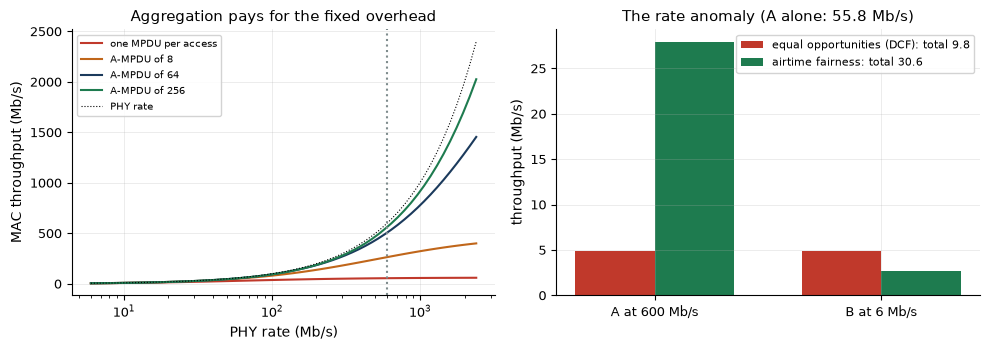

"600 Mb/s PHY, 1500-byte packets",throughput,efficiency
one MPDU per access,55.8 Mb/s,9.3%
A-MPDU of 64,507 Mb/s,84%


In [7]:
def mac_demo(phy=600.0, slow=6.0, n_agg=64):
    rates = np.logspace(np.log10(6), np.log10(2400), 60)
    fig, ax = lk.fig("row2", 1, 2)
    for na, col in [(1, lk.RED), (8, lk.ORANGE), (64, lk.NAVY), (256, lk.GREEN)]:
        ax[0].semilogx(rates, [iot.mac_exchange(r_, n_agg=na)[0] for r_ in rates], color=col, label=f"A-MPDU of {na}" if na > 1 else "one MPDU per access")
    ax[0].semilogx(rates, rates, "k:", lw=0.8, label="PHY rate")
    ax[0].axvline(phy, color=lk.GRAY, ls=":"); ax[0].set_xlabel("PHY rate (Mb/s)"); ax[0].set_ylabel("MAC throughput (Mb/s)")
    ax[0].legend(fontsize=7.5); ax[0].set_title("Aggregation pays for the fixed overhead")
    def exch(r_, na):
        thr, _ = iot.mac_exchange(r_, n_agg=na)
        return na * 12000 / (thr * 1e6), na                                      # duration and packets of one exchange
    tA, nA = exch(phy, n_agg); tB, nB = exch(slow, 1 if n_agg == 1 else max(1, min(n_agg, 4)))
    equal_op = [nA * 12000 / (tA + tB) / 1e6, nB * 12000 / (tA + tB) / 1e6]
    airtime = [0.5 * nA * 12000 / tA / 1e6, 0.5 * nB * 12000 / tB / 1e6]
    alone = nA * 12000 / tA / 1e6
    x = np.arange(2); w = 0.35
    ax[1].bar(x - w / 2, equal_op, w, color=lk.RED, label=f"equal opportunities (DCF): total {sum(equal_op):.1f}")
    ax[1].bar(x + w / 2, airtime, w, color=lk.GREEN, label=f"airtime fairness: total {sum(airtime):.1f}")
    ax[1].set_xticks(x); ax[1].set_xticklabels([f"A at {phy:g} Mb/s", f"B at {slow:g} Mb/s"]); ax[1].set_ylabel("throughput (Mb/s)")
    ax[1].legend(fontsize=8); ax[1].set_title(f"The rate anomaly (A alone: {alone:.1f} Mb/s)")
    lk.show(fig)
    t1, e1 = iot.mac_exchange(phy, n_agg=1); t64, e64 = iot.mac_exchange(phy, n_agg=64)
    lk.table([["one MPDU per access", f"{t1:.1f} Mb/s", f"{100 * e1:.1f}%"], ["A-MPDU of 64", f"{t64:.0f} Mb/s", f"{100 * e64:.0f}%"]],
             [f"{phy:g} Mb/s PHY, 1500-byte packets", "throughput", "efficiency"])

lk.interact(mac_demo, phy=lk.slider(600, 6, 2400, 6, "station A PHY rate (Mb/s)"), slow=lk.slider(6, 1, 100, 1, "station B PHY rate (Mb/s)"),
            n_agg=lk.choice([1, 8, 64], 1, "A-MPDU length for A"))

**What you should see.** Without aggregation, throughput saturates near 60 Mb/s however fast the PHY: at 600 Mb/s it is 55.8 Mb/s
(9.3%), and A-MPDUs of 64 lift it to 507 Mb/s (84%), as in the chapter. With one packet per access, station A at 600 Mb/s and station B
at 6 Mb/s each get about 4.9 Mb/s (9.8 Mb/s in all); airtime fairness gives A about 28 Mb/s and B about 2.7 Mb/s, three times the total.

### Try it yourself 2.1
Using `iot.mac_exchange`, what is the throughput (Mb/s) of a 2400 Mb/s Wi-Fi 6 link with A-MPDUs of 256?

In [9]:
answer_2_1 = None
lk.check("2.1 throughput at 2400 Mb/s, A-MPDU 256", answer_2_1, iot.mac_exchange(2400, n_agg=256)[0], atol=5)

[TODO] 2.1 throughput at 2400 Mb/s, A-MPDU 256: not attempted yet: replace the None with your answer

## 3. Rate adaptation

Wi-Fi has no CQI feedback: the transmitter learns which MCS works by trying. Linux's **Minstrel** keeps an exponentially weighted
success probability per rate, picks the rate with the best expected throughput every 100 ms, and spends about 10% of packets
"looking around" at other rates. Below, a station walks through a room (slow SNR swings) with Rician fast fading, 80 MHz, one stream.
(MCS SNR thresholds and rates follow Chapter 22's rate-range model.)

### Interactive: look-around rate and update interval

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

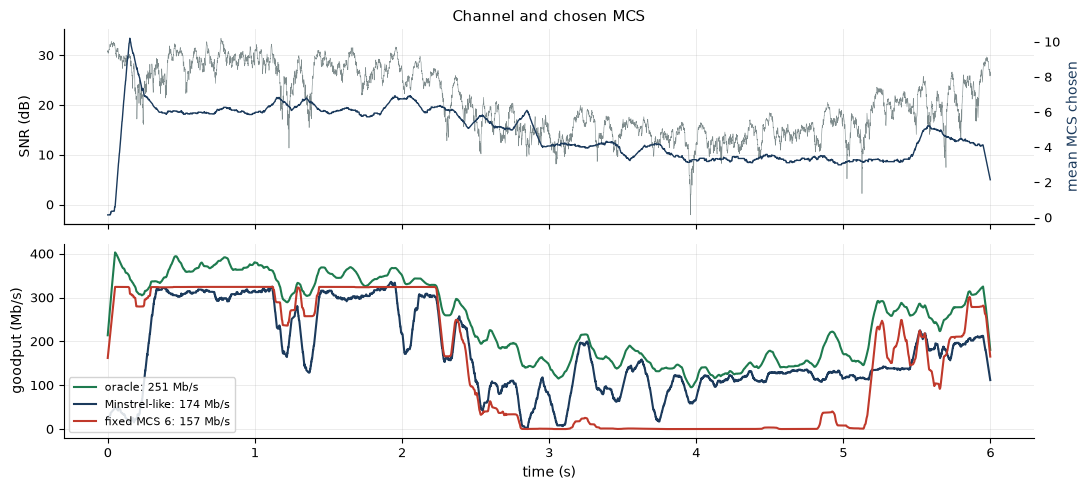

In [11]:
SNR_REQ = np.array([2, 5, 9, 11, 15, 18, 20, 25, 29, 31, 34, 37])
BITS = np.array([0.5, 1, 1.5, 2, 3, 4, 4.5, 5, 6, 6.67, 7.5, 8.33])
RATE80 = 980 * BITS / 13.6                                     # 80 MHz, 1 stream, 0.8 us GI (Mb/s)
per = lambda snr, m: 1 / (1 + np.exp(1.6 * (snr - SNR_REQ[m])))

def minstrel_demo(lookaround=0.10, update_ms=100, ewma=0.25, mean_snr=24.0):
    r = np.random.default_rng(7)
    T = 6000; t = np.arange(T) / 1000
    slow = mean_snr + 9 * np.sin(2 * np.pi * t / 6.0 + 0.6) + np.cumsum(r.standard_normal(T)) * 0.03
    fc = np.convolve(r.standard_normal(T) + 1j * r.standard_normal(T), np.ones(60) / np.sqrt(60), "same") / np.sqrt(2)
    snr = slow + lk.db(np.abs(np.sqrt(0.8) + np.sqrt(0.2) * fc) ** 2)
    oracle = ((1 - per(snr[:, None], np.arange(12)[None, :])) * RATE80[None, :]).max(axis=1)
    prob = np.full(12, 0.5); succ = np.zeros(12); att = np.zeros(12); cur = 0; got = np.zeros(T); chosen = np.zeros(T, int)
    for k in range(T):
        m = r.integers(0, 12) if r.random() < lookaround else cur
        ok = r.random() > per(snr[k], m)
        att[m] += 1; succ[m] += ok; got[k] = RATE80[m] * ok; chosen[k] = m
        if k % update_ms == update_ms - 1:
            upd = att > 0
            prob[upd] = (1 - ewma) * prob[upd] + ewma * succ[upd] / att[upd]
            succ[:] = 0; att[:] = 0
            cur = int(np.argmax(prob * RATE80 * (prob > 0.1)))
    fixed = (1 - per(snr, 6)) * RATE80[6]
    sm = lambda v: np.convolve(v, np.ones(100) / 100, "same")
    fig, ax = lk.fig((11, 5), 2, 1, sharex=True)
    ax[0].plot(t, snr, color=lk.GRAY, lw=0.4); ax2 = ax[0].twinx(); ax2.plot(t, sm(chosen), color=lk.NAVY, lw=1); ax2.set_ylabel("mean MCS chosen", color=lk.NAVY)
    ax2.grid(False); ax[0].set_ylabel("SNR (dB)"); ax[0].set_title("Channel and chosen MCS")
    ax[1].plot(t, sm(oracle), color=lk.GREEN, label=f"oracle: {oracle.mean():.0f} Mb/s")
    ax[1].plot(t, sm(got), color=lk.NAVY, label=f"Minstrel-like: {got.mean():.0f} Mb/s")
    ax[1].plot(t, sm(fixed), color=lk.RED, label=f"fixed MCS 6: {fixed.mean():.0f} Mb/s")
    ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("goodput (Mb/s)"); ax[1].legend(fontsize=8, loc="lower left")
    lk.show(fig)

lk.interact(minstrel_demo, lookaround=lk.slider(0.10, 0.0, 0.5, 0.01, "look-around fraction"), update_ms=lk.choice([20, 50, 100, 500, 1000], 100, "update interval (ms)"),
            ewma=lk.slider(0.25, 0.05, 1.0, 0.05, "EWMA weight"), mean_snr=lk.slider(24, 10, 40, 1, "mean SNR (dB)"))

**What you should see.** The algorithm follows the slow SNR swings and reaches roughly 70% of the oracle that knows the SNR of every
packet (the look-around packets and the 100 ms reaction time cost the rest), and beats the best fixed MCS, which collapses in the deep
stretch of the walk. Set the look-around fraction to zero: Minstrel can no longer discover that a higher rate has become
usable and gets stuck low after a fade. A very long update interval reacts too slowly; a very short one reacts to noise.

## 4. Bluetooth Low Energy: GFSK and battery life

BLE uses GFSK with $BT = 0.5$ and modulation index $h \approx 0.5$ at 1 Mb/s (LE 1M) or 2 Mb/s (LE 2M): a constant-envelope signal that
a cheap, saturated power amplifier can transmit and a limiter–discriminator can demodulate. Battery life is set by charge per event:
Chapter 22's beacon sends a 47-byte advertising packet (376 µs) on three channels per event, about 10.7 µC with the processor, plus
2 µA of sleep current, from a 225 mAh CR2032: about 86 days at 100 ms, 2.0 years at 1 s, 8.4 years at 10 s.

### Interactive: modulation index, BT and SNR

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

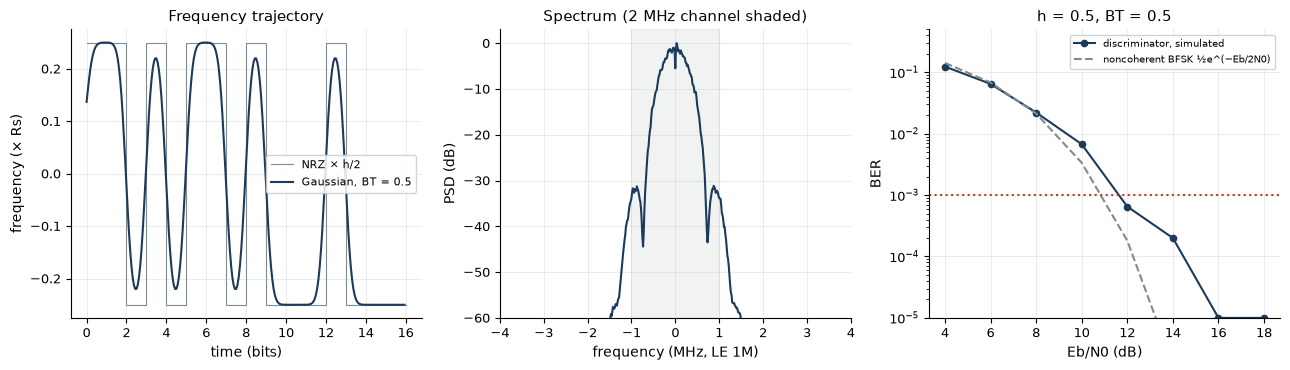

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

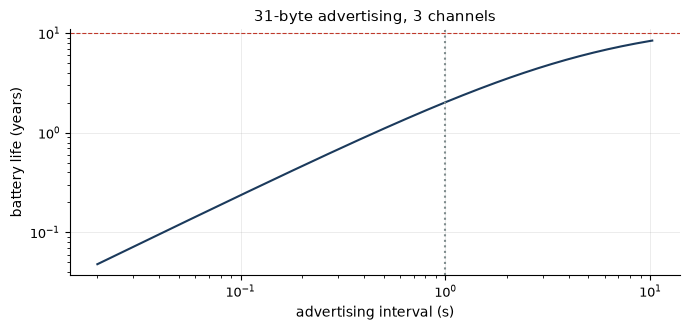

,
packet length / air time,47 bytes / 376 µs
charge per event,10.7 µC
average current,12.7 µA
battery life,2.03 years (740 days)


In [13]:
def ble_ber(snr_db, h=0.5, bt=0.5, n=20000, sps=8, r=None):
    bits = r.integers(0, 2, n)
    x, _ = iot.gfsk_mod(bits, sps=sps, bt=bt, h=h)
    y = x + np.sqrt(sps / lk.undb(snr_db)) * cn(r, len(x))           # SNR per bit (Eb/N0)
    from scipy.signal import firwin
    y = np.convolve(y, firwin(4 * sps + 1, 1.6 / sps), "same")         # receive filter of about ±0.8 MHz (LE 1M)
    fd = np.r_[0, iot.fm_discriminator(y)]
    dec = np.add.reduceat(fd, np.arange(0, len(fd), sps)) > 0         # integrate and dump
    return np.mean(dec[2:-2] != bits[2:-2])

def ble_demo(h=0.5, bt=0.5, snr_db=14.0):
    r = np.random.default_rng(5)
    sps = 16
    bits = r.integers(0, 2, 2000)
    x, f = iot.gfsk_mod(bits, sps=sps, bt=bt, h=h)
    fig, ax = lk.fig((13, 3.8), 1, 3)
    tt = np.arange(16 * sps) / sps
    ax[0].step(np.arange(17), np.r_[2 * bits[:16] - 1, 2 * bits[15] - 1] * h / 2, where="post", color=lk.GRAY, lw=0.8, label="NRZ × h/2")
    ax[0].plot(tt, f[:16 * sps], color=lk.NAVY, label=f"Gaussian, BT = {bt:g}")
    ax[0].set_xlabel("time (bits)"); ax[0].set_ylabel("frequency (× Rs)"); ax[0].legend(fontsize=8); ax[0].set_title("Frequency trajectory")
    fr, p = welch(x, fs=16.0, nperseg=1024, return_onesided=False); i = np.argsort(fr)
    ax[1].plot(fr[i], lk.db(p[i] / p.max()), color=lk.NAVY); ax[1].axvspan(-1, 1, color=lk.GRAY, alpha=0.1)
    ax[1].set_xlim(-4, 4); ax[1].set_ylim(-60, 3); ax[1].set_xlabel("frequency (MHz, LE 1M)"); ax[1].set_ylabel("PSD (dB)"); ax[1].set_title("Spectrum (2 MHz channel shaded)")
    snrs = np.arange(4, 19, 2.0)
    ax[2].semilogy(snrs, [max(ble_ber(s_, h, bt, r=r), 1e-5) for s_ in snrs], "o-", color=lk.NAVY, label="discriminator, simulated")
    ax[2].semilogy(snrs, 0.5 * np.exp(-lk.undb(snrs) / 2), "--", color=lk.GRAY, label="noncoherent BFSK ½e^(−Eb/2N0)")
    ax[2].axhline(1e-3, color=lk.RED, ls=":"); ax[2].set_ylim(1e-5, 0.5); ax[2].legend(fontsize=7.5)
    ax[2].set_xlabel("Eb/N0 (dB)"); ax[2].set_ylabel("BER"); ax[2].set_title(f"h = {h:g}, BT = {bt:g}")
    lk.show(fig)

lk.interact(ble_demo, h=lk.slider(0.5, 0.3, 1.0, 0.05, "modulation index h"), bt=lk.choice([0.3, 0.5, 1.0], 0.5, "BT"),
            snr_db=lk.slider(14, 0, 30, 1, "SNR (dB)"))

def battery_demo(interval_s=1.0, payload=31, i_tx_ma=6.0, i_sleep_ua=2.0, cap_mah=225.0):
    nbytes = 1 + 4 + 2 + 6 + payload + 3
    t_pkt = nbytes * 8 / 1e6
    q = 3 * (t_pkt + 0.15e-3) * i_tx_ma * 1e-3 + 0.4e-3 * 3e-3
    iv = np.logspace(np.log10(0.02), np.log10(10.24), 200)
    life = lambda T: cap_mah * 1e-3 / (q / T + i_sleep_ua * 1e-6) / 24 / 365
    fig, ax = lk.fig((7, 3.4))
    ax.loglog(iv, life(iv), color=lk.NAVY); ax.axvline(interval_s, color=lk.GRAY, ls=":"); ax.axhline(10, color=lk.RED, ls="--", lw=0.8)
    ax.set_xlabel("advertising interval (s)"); ax.set_ylabel("battery life (years)"); ax.set_title(f"{payload}-byte advertising, 3 channels")
    lk.show(fig)
    lk.table([["packet length / air time", f"{nbytes} bytes / {t_pkt * 1e6:.0f} µs"], ["charge per event", f"{q * 1e6:.1f} µC"],
              ["average current", f"{(q / interval_s + i_sleep_ua * 1e-6) * 1e6:.1f} µA"],
              ["battery life", f"{life(interval_s):.2f} years ({life(interval_s) * 365:.0f} days)"]], ["", ""])

lk.interact(battery_demo, interval_s=lk.choice([0.1, 1.0, 10.0], 1.0, "advertising interval (s)"), payload=lk.islider(31, 0, 31, 1, "payload (bytes)"),
            i_tx_ma=lk.slider(6, 3, 20, 0.5, "TX current (mA)"), i_sleep_ua=lk.slider(2, 0.3, 10, 0.1, "sleep current (µA)"), cap_mah=lk.slider(225, 50, 1000, 5, "cell capacity (mAh)"))

**What you should see.** A smooth Gaussian frequency trajectory and a compact spectrum that fits the 2 MHz channel. The discriminator
needs about 11–12 dB of $E_b/N_0$ for $10^{-3}$, within a dB or so of noncoherent FSK: BLE trades sensitivity for an extremely simple receiver.
The battery table reproduces the chapter: 376 µs packets, about 10.7 µC per event, 12.7 µA and about 2.0 years at 1 s; at 10 s the 2 µA
sleep current dominates. Lower $h$ to 0.3 and the discriminator BER worsens: the frequency deviation shrinks against the noise.

### Try it yourself 4.1
With the chapter's numbers, what is the average current (µA) of a beacon advertising every 100 ms?

In [15]:
answer_4_1 = None
lk.check("4.1 average current at 100 ms (uA)", answer_4_1, 107 + 2, atol=2)

[TODO] 4.1 average current at 100 ms (uA): not attempted yet: replace the None with your answer

## 5. IEEE 802.15.4: chips and O-QPSK

Zigbee, Thread and Matter run on the 2.4 GHz 802.15.4 PHY: each 4-bit symbol becomes one of 16 nearly orthogonal 32-chip sequences
(2 Mchip/s, so 250 kb/s), sent as half-sine offset-QPSK, which is exactly MSK: constant envelope again. The receiver correlates with
all 16 sequences and picks the largest: 32 chips for 4 bits is a processing gain of 9 dB.

### Interactive: SNR

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

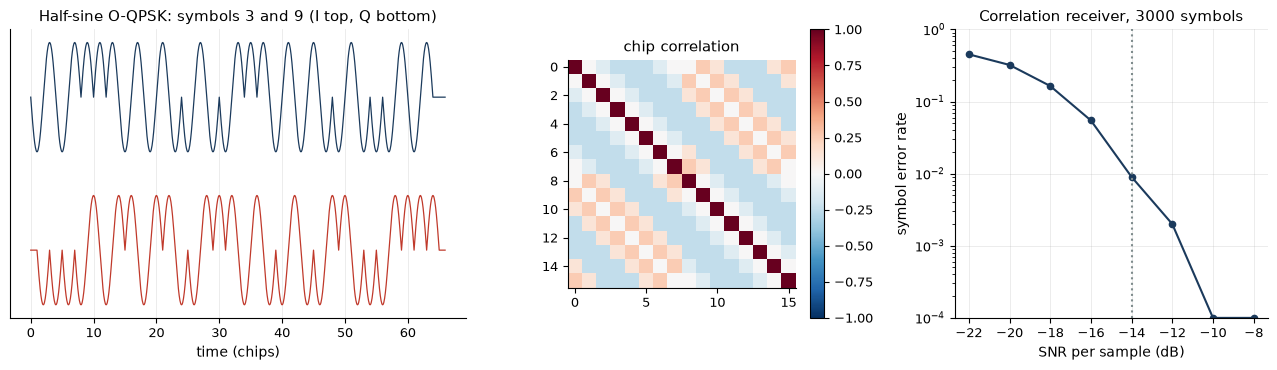

,
max |off-diagonal correlation|,0.25
SER at -14 dB,0.011
bit rate / chip rate,250 kb/s / 2 Mchip/s


In [17]:
TAB = iot.ieee802154_chips()

def zb_demo(snr_db=-14.0, n_sym=3000):
    r = np.random.default_rng(9)
    sps = 8
    B = 2.0 * TAB - 1
    C = B @ B.T / 32
    sym = r.integers(0, 16, n_sym)
    x = iot.oqpsk_halfsine(TAB[sym].ravel(), sps=sps)
    def ser(s_db):
        y = x + np.sqrt(1 / lk.undb(s_db)) * cn(r, len(x))           # SNR per sample in the chip bandwidth (sps samples/chip)
        p = np.sin(np.pi * np.arange(2 * sps) / (2 * sps))
        mi = np.convolve(y.real, p[::-1])[2 * sps - 1::2 * sps][:16 * n_sym]
        mq = np.convolve(y.imag, p[::-1])[3 * sps - 1::2 * sps][:16 * n_sym]
        chips = np.empty(32 * n_sym); chips[0::2] = mi; chips[1::2] = mq
        dec = np.argmax(chips.reshape(n_sym, 32) @ B.T, axis=1)
        return np.mean(dec != sym)
    fig, ax = lk.fig((13, 3.8), 1, 3, gridspec_kw=dict(width_ratios=[1.6, 1, 1.1]))
    xs = iot.oqpsk_halfsine(TAB[[3, 9]].ravel(), sps=16); t = np.arange(len(xs)) / 16
    ax[0].plot(t, xs.real + 1.4, color=lk.NAVY, lw=0.9); ax[0].plot(t, xs.imag - 1.4, color=lk.RED, lw=0.9); ax[0].set_yticks([])
    ax[0].set_xlabel("time (chips)"); ax[0].set_title("Half-sine O-QPSK: symbols 3 and 9 (I top, Q bottom)")
    im = ax[1].imshow(C, cmap="RdBu_r", vmin=-1, vmax=1); ax[1].grid(False); plt.colorbar(im, ax=ax[1]); ax[1].set_title("chip correlation")
    snrs = np.arange(-22, -7, 2.0)
    ax[2].semilogy(snrs, np.maximum([ser(s_) for s_ in snrs], 1e-4), "o-", color=lk.NAVY)
    ax[2].axvline(snr_db, color=lk.GRAY, ls=":"); ax[2].set_ylim(1e-4, 1)
    ax[2].set_xlabel("SNR per sample (dB)"); ax[2].set_ylabel("symbol error rate"); ax[2].set_title(f"Correlation receiver, {n_sym} symbols")
    lk.show(fig)
    off = C[~np.eye(16, dtype=bool)]
    lk.table([["max |off-diagonal correlation|", f"{np.abs(off).max():.2f}"], [f"SER at {snr_db:g} dB", f"{ser(snr_db):.3g}"],
              ["bit rate / chip rate", "250 kb/s / 2 Mchip/s"]], ["", ""])

lk.interact(zb_demo, snr_db=lk.slider(-14, -24, 0, 1, "SNR (dB)"), n_sym=lk.choice([1000, 3000, 10000], 3000, "symbols"))

**What you should see.** The I and Q half-sines are offset by one chip, so the envelope never passes through zero. The 16 sequences have
off-diagonal correlations of at most about 0.25 in magnitude: not orthogonal, but close. The correlation receiver works at a per-sample SNR
of about −14 dB: 8 samples per chip and 32 chips per 4-bit symbol add up to about 18 dB of combining gain.

## 6. LoRa and RFID: chirps, SER, time on air and range

A LoRa symbol of spreading factor SF is a linear chirp across the bandwidth $B$, cyclically shifted by its value $0..2^{SF}-1$. The
receiver multiplies by a down-chirp ("dechirp"), which turns every symbol into a tone, and takes an FFT: the peak bin is the symbol.
This is noncoherent $M$-ary orthogonal signalling with $M = 2^{SF}$, and each SF step buys about 2.5 dB of sensitivity for half the
rate. Chapter 22's link budget: 14 dBm EIRP, 3 dBi gateway antenna, 10 dB margin: sensitivity −124.5 dBm (SF7) and −137 dBm (SF12),
time on air for 20 bytes 56.6 ms and 1.32 s, urban range 0.73 km and 1.7 km. And a UHF RFID tag: 4 W EIRP at 915 MHz, a −22 dBm chip
and 3 dB polarisation loss give a read range of 18.8 m.

### Interactive: spreading factor and SNR

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

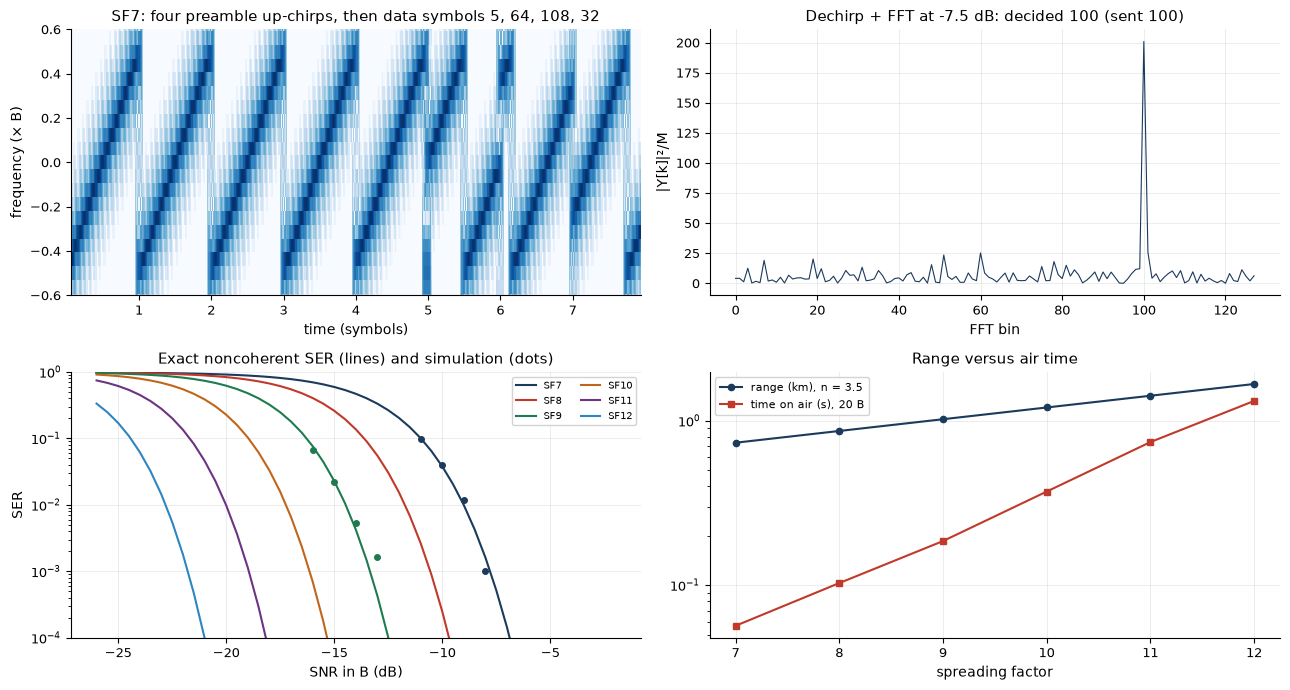

"SF7, 125 kHz",
symbol time 2^SF/B,1.024 ms
raw bit rate,5469 b/s
sensitivity,-124.5 dBm
"time on air, 20 bytes",56.6 ms
minimum gap at 1% duty cycle,5.6 s
max packets per hour at 1%,636
"range with 10 dB margin, n = 3.5",0.73 km


"UHF RFID, 4 W EIRP, tag chip sensitivity",read range
-15 dBm,8.4 m
-22 dBm,18.8 m
backscatter at 10 m,-65 dBm


In [19]:
def lora_demo(sf=7, snr_db=-7.5, payload=20, n_env=3.5):
    r = np.random.default_rng(2)
    M = 2 ** sf
    osr = 4
    x = np.concatenate([iot.lora_symbols(sf, [0] * 4, osr), iot.lora_symbols(sf, [5, M // 2, M - 20, M // 4], osr)])
    fig, ax = lk.fig((13, 7), 2, 2)
    f, t, S = spectrogram(x, fs=osr, nperseg=64, noverlap=56, return_onesided=False, detrend=False); i = np.argsort(f)
    ax[0, 0].pcolormesh(t / M, f[i], lk.db(S[i] + 1e-6), cmap="Blues", shading="auto", vmin=-25); ax[0, 0].grid(False)
    ax[0, 0].set_ylim(-0.6, 0.6); ax[0, 0].set_xlabel("time (symbols)"); ax[0, 0].set_ylabel("frequency (× B)")
    ax[0, 0].set_title(f"SF{sf}: four preamble up-chirps, then data symbols 5, {M // 2}, {M - 20}, {M // 4}")
    s = iot.lora_symbols(sf, [100 % M])
    y = s + 10 ** (-snr_db / 20) * cn(r, M)
    d, X = iot.lora_demod(y, sf)
    ax[0, 1].plot(X[0] ** 2 / M, color=lk.NAVY, lw=0.8); ax[0, 1].set_xlabel("FFT bin"); ax[0, 1].set_ylabel("|Y[k]|²/M")
    ax[0, 1].set_title(f"Dechirp + FFT at {snr_db:g} dB: decided {d[0]} (sent {100 % M})")
    snr = np.linspace(-26, -2, 49)
    for s_, col in zip(range(7, 13), lk.PALETTE):
        th = iot.lora_ser_theory(s_, snr)
        ax[1, 0].semilogy(snr, th, color=col, label=f"SF{s_}")
    for s_, col in zip((7, 9), lk.PALETTE[::2]):
        req = np.interp(-3, np.log10(iot.lora_ser_theory(s_, snr)[::-1] + 1e-30), snr[::-1])
        pts = np.arange(round(req) - 3, round(req) + 2, 1.0)
        sim = np.array([iot.lora_ser_sim(s_, p_, 3000, rng=s_ * 10 + int(p_ + 30)) for p_ in pts])
        ax[1, 0].semilogy(pts[sim > 0], sim[sim > 0], "o", color=col, ms=4)
    ax[1, 0].set_ylim(1e-4, 1); ax[1, 0].set_xlabel("SNR in B (dB)"); ax[1, 0].set_ylabel("SER"); ax[1, 0].legend(fontsize=7, ncol=2)
    ax[1, 0].set_title("Exact noncoherent SER (lines) and simulation (dots)")
    sfs = np.arange(7, 13)
    pl0 = 20 * np.log10(4 * np.pi * 868e6 / 3e8)
    mapl = 14 + 3 - np.array([iot.lora_sensitivity_dbm(s_) for s_ in sfs]) - 10
    ax[1, 1].semilogy(sfs, 10 ** ((mapl - pl0) / (10 * n_env)) / 1e3, "o-", color=lk.NAVY, label=f"range (km), n = {n_env:g}")
    ax[1, 1].semilogy(sfs, [iot.lora_time_on_air(payload, s_) for s_ in sfs], "s-", color=lk.RED, label=f"time on air (s), {payload} B")
    ax[1, 1].set_xlabel("spreading factor"); ax[1, 1].legend(fontsize=8); ax[1, 1].set_title("Range versus air time")
    lk.show(fig)
    toa = iot.lora_time_on_air(payload, sf)
    lk.table([["symbol time 2^SF/B", f"{M / 125e3 * 1e3:.3f} ms"], ["raw bit rate", f"{iot.lora_bitrate(sf):.0f} b/s"],
              ["sensitivity", f"{iot.lora_sensitivity_dbm(sf):.1f} dBm"], [f"time on air, {payload} bytes", f"{toa * 1e3:.1f} ms"],
              ["minimum gap at 1% duty cycle", f"{99 * toa:.1f} s"], ["max packets per hour at 1%", f"{3600 * 0.01 / toa:.0f}"],
              [f"range with 10 dB margin, n = {n_env:g}", f"{10 ** ((14 + 3 - iot.lora_sensitivity_dbm(sf) - 10 - pl0) / (10 * n_env)) / 1e3:.2f} km"]], [f"SF{sf}, 125 kHz", ""])
    lam = 3e8 / 915e6
    lk.table([[f"{th_} dBm", f"{iot.rfid_forward_range(4, 915e6, p_th_w=1e-3 * lk.undb(th_), pol_loss=2):.1f} m"] for th_ in (-15, -22)] +
             [["backscatter at 10 m", f"{iot.rfid_backscatter_dbm(10, 36, 915e6):.0f} dBm"]], ["UHF RFID, 4 W EIRP, tag chip sensitivity", "read range"])

lk.interact(lora_demo, sf=lk.islider(7, 7, 12, 1, "spreading factor"), snr_db=lk.slider(-7.5, -25, 5, 0.5, "SNR (dB)"),
            payload=lk.islider(20, 1, 51, 1, "payload (bytes)"), n_env=lk.slider(3.5, 2.0, 4.5, 0.1, "path-loss exponent"))

**What you should see.** The spectrogram shows the sawtooth chirps, each data symbol starting at a different frequency. After dechirping
at −7.5 dB SNR, one FFT bin stands far above the rest: the $2^7 = 128$ chips of SF7 give 21 dB of processing gain. The simulated SER
matches the exact formula, and each SF step moves the curve about 2.5 dB left. The tables reproduce the chapter: −124.5 dBm and 56.6 ms
at SF7 (switch to SF12: −137 dBm, 1.32 s, 131 s between packets at 1% duty cycle, about 27 packets an hour), 0.73 km (SF7) and 1.7 km
(SF12) urban range, and an RFID read range of 18.8 m for a −22 dBm chip (8.4 m at −15 dBm) with −65 dBm backscattered at 10 m.

### Try it yourself 6.1
What is LoRa's raw bit rate (b/s) at SF10, 125 kHz, coding rate 4/5?

In [21]:
answer_6_1 = None
lk.check("6.1 LoRa SF10 bit rate (b/s)", answer_6_1, iot.lora_bitrate(10), atol=1)

[TODO] 6.1 LoRa SF10 bit rate (b/s): not attempted yet: replace the None with your answer

## Key takeaways
* 802.11 receivers detect packets with the STF's delay correlation, correct frequency in two stages and estimate the channel from the LTF.
* Per-access overhead of about 200 µs makes aggregation essential at high PHY rates; equal opportunities at unequal rates waste airtime.
* Wi-Fi rate adaptation learns by trial (Minstrel): looking around is what lets it climb back after a fade.
* BLE: constant-envelope GFSK and aggressive sleeping; battery life saturates at the sleep current.
* 802.15.4: 4 bits → 32 chips → MSK-like O-QPSK; correlation receivers work below 0 dB SNR.
* LoRa: chirps + dechirp/FFT = noncoherent orthogonal signalling; each SF doubles air time for 2.5 dB of sensitivity. RFID range is set by the forward link.

## Going further (hardware: USRP B200 / GNU Radio)
* Capture 20 MS/s at a busy 2.4 GHz Wi-Fi channel with `gnuradio/gr01_spectrum_iq_capture.py` and run `wifi_sync` on the capture: you
  will detect real packets and measure each station's frequency offset (a fingerprint of its crystal).
* Capture LoRa transmissions at 868/915 MHz (1 MS/s is enough for 125 kHz) and demodulate them with `iot.lora_demod` after finding the preamble.

## Exercises
1. **(Warm-up)** Show that the L-STF has period 16 samples because only every fourth subcarrier is used.
2. **(Core)** Add a coherent (Viterbi) GFSK receiver to Section 4 and measure its gain over the discriminator.
3. **(Core)** Simulate LoRaWAN capacity: pure ALOHA with $N$ devices on one channel at SF7 and SF12, with and without the capture effect.
4. **(Stretch)** Implement the full 802.11a receiver for one OFDM data symbol using the LTF channel estimate and the four pilot subcarriers.

In [23]:
lk.summary()

[good] Lab 31 finished in 5.0 s. Self-checks: 0 passed, 0 failed, 4 still to do.